In [ ]:
'''Script to plot and analyze UIT actual selector responses'''

In [1]:
import os
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import glob

In [3]:
pwd

'C:\\Users\\lenovo\\OneDrive - Politecnico di Milano\\Work_cloud\\DOTTORATO\\Modelling\\Pilot_plant\\UIT controller\\UIT_selector_operative'

In [12]:
# Function to read .csv files using 'glob' to find all files that contains a string in its filename
# Concatenate them
# Returns a dictionary
# Alternative, insert a while loop for dates (add input 'start_date' and 'end_date')
def read_csv_files(strings_list):
    # Create an empty dictionary to store DataFrames
    result_dict = {}

    # Loop through the list of strings
    for string in strings_list:
        # Generate the pattern to match filenames containing the string and any date
        pattern = f"{string}_*.csv"

        # Use glob to get a list of matching filenames
        matching_filenames = glob.glob(pattern)

        # Check if any matching files were found
        if matching_filenames:
            # Read and concatenate all matching CSV files into a DataFrame
            dfs = [pd.read_csv(filename) for filename in matching_filenames]
            result_dict[string] = pd.concat(dfs, ignore_index=True)

    return result_dict

# Example usage:
strings_list = ['Output_selector', 'Buondary_calc_conditions','Header','Follower']

result = read_csv_files(strings_list)

In [ ]:
#READ TXT FILES
# Do it just with Ctrl+F to find error strings in the log

In [13]:
# Computation of dosed tomato
# Convert 'timestamp' to datetime if it's not already in datetime format
df = result['Output_selector']
df['Timestamp_control'] = pd.to_datetime(df['Timestamp_control'])

# Group by day and calculate the sum for each group
on_minutes_tot_daily_sum = df.groupby(df['Timestamp_control'].dt.date)['on_minutes_tot'].sum().reset_index()
on_minutes_tot_daily_sum['on_minutes_tot'] = on_minutes_tot_daily_sum['on_minutes_tot']*10 #mL/day

# Define a function to perform the operation for each day
def process_day(day_df):
    # Multiply each value in the selected rows by 10, add 10, and compute the sum
    day_sum = (day_df['final_control_signal']*1e6*2.5/24 + 96*2.5/24).sum()
    return pd.DataFrame({'date': [day_df['Timestamp_control'].iloc[0].date()], 'day_sum': [day_sum]})

# Apply the function for each day in the original DataFrame
final_control_signal_daily_sum = df.groupby(df['Timestamp_control'].dt.date).apply(process_day).reset_index(drop=True)

# Concatenate the two DataFrames
result_combined = pd.concat([on_minutes_tot_daily_sum, final_control_signal_daily_sum], axis=1)

# Print the resulting DataFrame
print(result_combined)

   Timestamp_control  on_minutes_tot        date     day_sum
0         2024-01-31              50  2024-01-31   52.898618
1         2024-02-01             100  2024-02-01  102.887830
2         2024-02-02             160  2024-02-02  152.048288
3         2024-02-03             210  2024-02-03  202.209112
4         2024-02-04             220  2024-02-04  227.020600
5         2024-02-05             200  2024-02-05  201.501095
6         2024-02-06             170  2024-02-06  172.445821
7         2024-02-07              50  2024-02-07   48.849620
8         2024-02-08              30  2024-02-08   21.841921
9         2024-02-09              70  2024-02-09   78.393739
10        2024-02-10              70  2024-02-10   70.473992
11        2024-02-11              70  2024-02-11   81.425924


In [4]:
# PLOT of boundary conditions
df = result['Buondary_calc_conditions']
# Plot the overall time series
plt.figure(figsize=(12, 6))
plt.plot(df1['Timestamp_control'], df1['ch4_measure'], color='r', label='ch4_measure',linewidth=0.5,marker='o')
plt.plot(df1['Timestamp_control'], df1['ch4_setpoint'], color='b', label='ch4_setpoint',linewidth=0.5,marker='o')
plt.xlabel('Timestamp')
plt.ylabel('Variable Value')
plt.title('Overall Time Series')
plt.legend()
plt.xticks(rotation=90)
plt.tight_layout()
ax = plt.gca()
#ax.set_xlim([xmin, xmax])
#ax.set_ylim([0, 10])

# Set x-axis formatting to display dates as 'YYYY-MM-DD'
date_format = mdates.DateFormatter('%Y-%m-%d')
ax.xaxis.set_major_formatter(date_format)

# Set the locator for the x-axis to show every day
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))

# Set x-axis limits with timestamps (from 10:30 AM to 12:30 PM)
start_time = '2024-01-31 00:00:00'
end_time = '2024-02-03 00:00:00'
plt.xlim(mdates.date2num(np.datetime64(start_time)), mdates.date2num(np.datetime64(end_time)))
ax = plt.gca()

#ax.set_ylim([42, 42.4])
#ax.set_xlim([15000,15015])

# Set x-axis formatting to display dates as 'YYYY-MM-DD'
date_format = mdates.DateFormatter('%Y-%m-%d %H') #('%Y-%m-%d %H:%m')
ax.xaxis.set_major_formatter(date_format)

# Set the locator for the x-axis to show every day
ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))

plt.grid()
plt.show()

NameError: name 'df1' is not defined

<Figure size 1200x600 with 0 Axes>

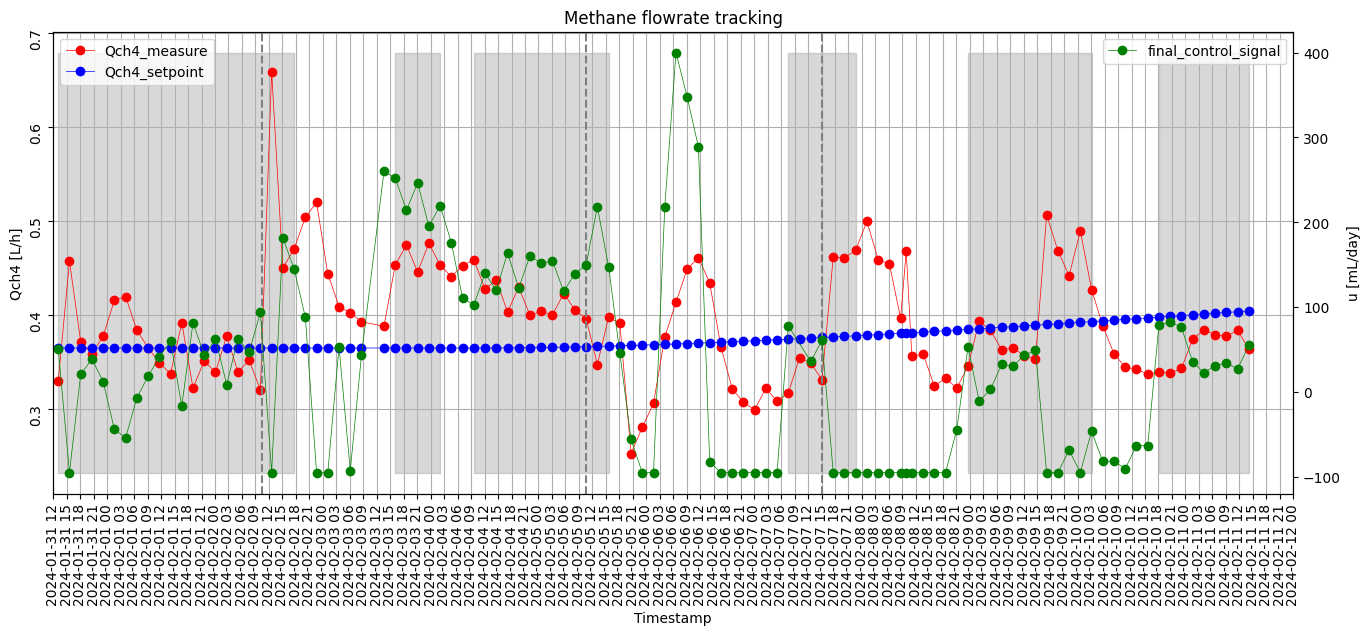

In [15]:
# PLOT of boundary conditions + outputs
df1 = result['Buondary_calc_conditions']
df2 = result['Output_selector']
df1['Timestamp_control'] = pd.to_datetime(df1['Timestamp_control'])
df2['Timestamp_control'] = pd.to_datetime(df2['Timestamp_control'])
# Plot the overall time series
fig, ax1 = plt.subplots(figsize=(16, 6))
ax1.plot(df1['Timestamp_control'], df1['ch4_measure'], color='r', label='Qch4_measure',linewidth=0.5,marker='o')
ax1.plot(df1['Timestamp_control'], df1['ch4_setpoint'], color='b', label='Qch4_setpoint',linewidth=0.5,marker='o')
ax1.set_xlabel('Timestamp')
ax1.set_ylabel('Qch4 [L/h]')
ax1.legend(loc='upper left')
#ax = plt.gca()
#-----------------------------------------------------------------------------------------------------
# Create a second y-axis sharing the same x-axis
ax2 = ax1.twinx()
ax2.plot(df2['Timestamp_control'], df2['final_control_signal']*1e6, color='g', label='final_control_signal',linewidth=0.5,marker='o')
ax2.set_ylabel('u [mL/day]')
ax2.legend(loc='upper right')
#-----------------------------------------------------------------------------------------------------
# Add vertical dotted lines at specific time instants
specific_time_instants = ['2024-1-31 10:30','2024-2-2 10:30',
                          '2024-2-5 10:30','2024-2-7 15:00'
                         ]
for time_instant in specific_time_instants:
    ax1.axvline(pd.to_datetime(time_instant), color='grey', linestyle='dashed')#, label=f'{time_instant}')
#----------------------------------------------------------------------------------------------------
# Set x-axis formatting to display dates as 'YYYY-MM-DD'
date_format = mdates.DateFormatter('%Y-%m-%d')
ax2.xaxis.set_major_formatter(date_format)

# Set the locator for the x-axis to show every day
ax2.xaxis.set_major_locator(mdates.DayLocator(interval=1))

# Set x-axis limits with timestamps (from 10:30 AM to 12:30 PM)
start_time = '2024-01-31 12:00:00'
end_time = '2024-02-12 00:00:00'
ax2.set_xlim(mdates.date2num(np.datetime64(start_time)), mdates.date2num(np.datetime64(end_time)))
#ax = plt.gca()

#ax.set_ylim([42, 42.4])
#ax.set_xlim([15000,15015])

# Set x-axis formatting to display dates as 'YYYY-MM-DD'
date_format = mdates.DateFormatter('%Y-%m-%d %H') #('%Y-%m-%d %H:%m')
ax2.xaxis.set_major_formatter(date_format)

# Set the locator for the x-axis to show every day
ax2.xaxis.set_major_locator(mdates.HourLocator(interval=3))

# Fill the area where the specified column contains the specified value with grey color
mask = df2['active'] == 'Header'
ax1.fill_between(df2['Timestamp_control'], ax1.get_ylim()[0], ax1.get_ylim()[1], where=mask, color='grey', alpha=0.3)

plt.title('Methane flowrate tracking')
ax1.tick_params(rotation=90)
#ax1.tight_layout()
ax1.grid()
plt.show()

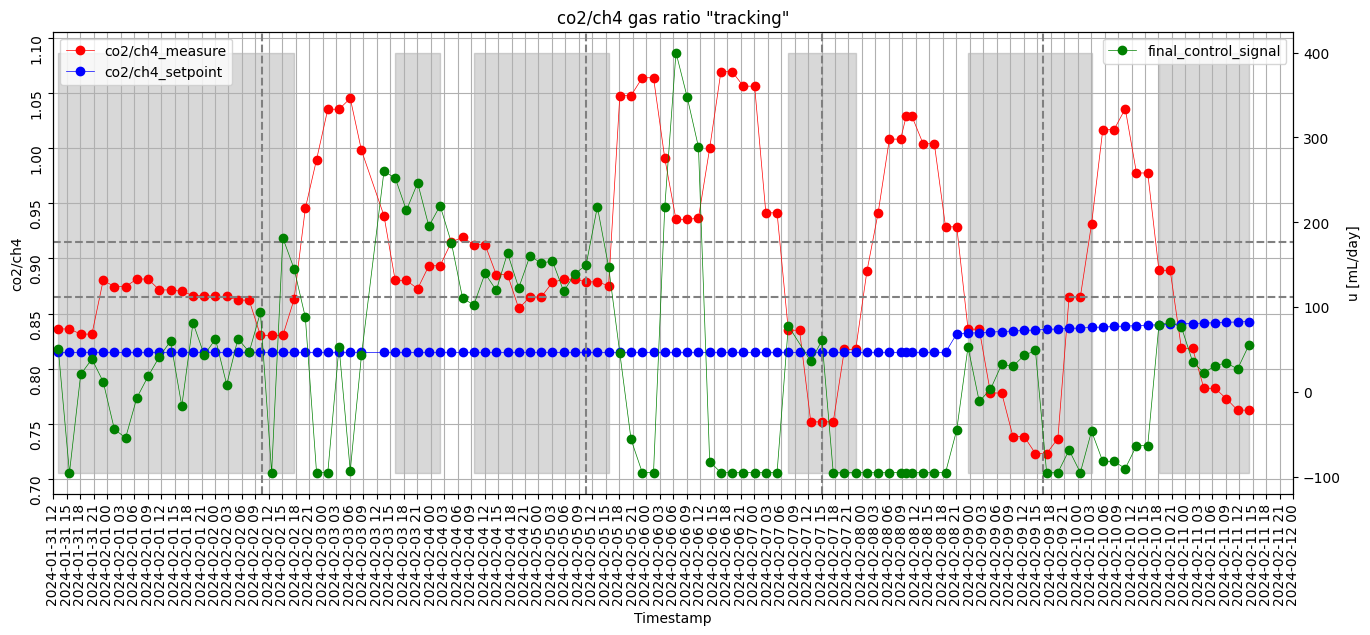

In [16]:
# PLOT of boundary conditions + outputs
df1 = result['Buondary_calc_conditions']
df2 = result['Output_selector']
df1['Timestamp_control'] = pd.to_datetime(df1['Timestamp_control'])
df2['Timestamp_control'] = pd.to_datetime(df2['Timestamp_control'])
# Plot the overall time series
fig, ax1 = plt.subplots(figsize=(16, 6))
ax1.plot(df1['Timestamp_control'], df1['co2/ch4_measure'], color='r', label='co2/ch4_measure',linewidth=0.5,marker='o')
ax1.plot(df1['Timestamp_control'], df1['co2/ch4_setpoint'], color='b', label='co2/ch4_setpoint',linewidth=0.5,marker='o')
ax1.set_xlabel('Timestamp')
ax1.set_ylabel('co2/ch4')
ax1.legend(loc='upper left')
#ax = plt.gca()
#-----------------------------------------------------------------------------------------------------
# Create a second y-axis sharing the same x-axis
ax2 = ax1.twinx()
ax2.plot(df2['Timestamp_control'], df2['final_control_signal']*1e6, color='g', label='final_control_signal',linewidth=0.5,marker='o')
ax2.set_ylabel('u [mL/day]')
ax2.legend(loc='upper right')
#-----------------------------------------------------------------------------------------------------
# Add vertical dotted lines at specific time instants
specific_time_instants = ['2024-1-31 10:30','2024-2-2 10:30',
                          '2024-2-5 10:30','2024-2-7 15:00','2024-2-9 16:15'
                         ]
for time_instant in specific_time_instants:
    ax1.axvline(pd.to_datetime(time_instant), color='grey', linestyle='dashed')#, label=f'{time_instant}')
#----------------------------------------------------------------------------------------------------
# Set x-axis formatting to display dates as 'YYYY-MM-DD'
date_format = mdates.DateFormatter('%Y-%m-%d')
ax2.xaxis.set_major_formatter(date_format)

# Set the locator for the x-axis to show every day
ax2.xaxis.set_major_locator(mdates.DayLocator(interval=1))

# Set x-axis limits with timestamps (from 10:30 AM to 12:30 PM)
start_time = '2024-01-31 12:00:00'
end_time = '2024-02-12 00:00:00'
ax2.set_xlim(mdates.date2num(np.datetime64(start_time)), mdates.date2num(np.datetime64(end_time)))
#ax = plt.gca()

#ax.set_ylim([42, 42.4])
#ax.set_xlim([15000,15015])

# Set x-axis formatting to display dates as 'YYYY-MM-DD'
date_format = mdates.DateFormatter('%Y-%m-%d %H') #('%Y-%m-%d %H:%m')
ax2.xaxis.set_major_formatter(date_format)

# Set the locator for the x-axis to show every day
ax2.xaxis.set_major_locator(mdates.HourLocator(interval=3))

ax1.axhline(0.814834862+0.05, color='grey', linestyle='dashed', label='uHigh')
ax1.axhline(0.814834862+0.1, color='grey', linestyle='dashed', label='uLow')

# Fill the area where the specified column contains the specified value with grey color
mask = df2['active'] == 'Header'
ax1.fill_between(df2['Timestamp_control'], ax1.get_ylim()[0], ax1.get_ylim()[1], where=mask, color='grey', alpha=0.3)

plt.title('co2/ch4 gas ratio "tracking"')
ax1.tick_params(rotation=90)
#ax1.tight_layout()
ax1.grid()
plt.show()

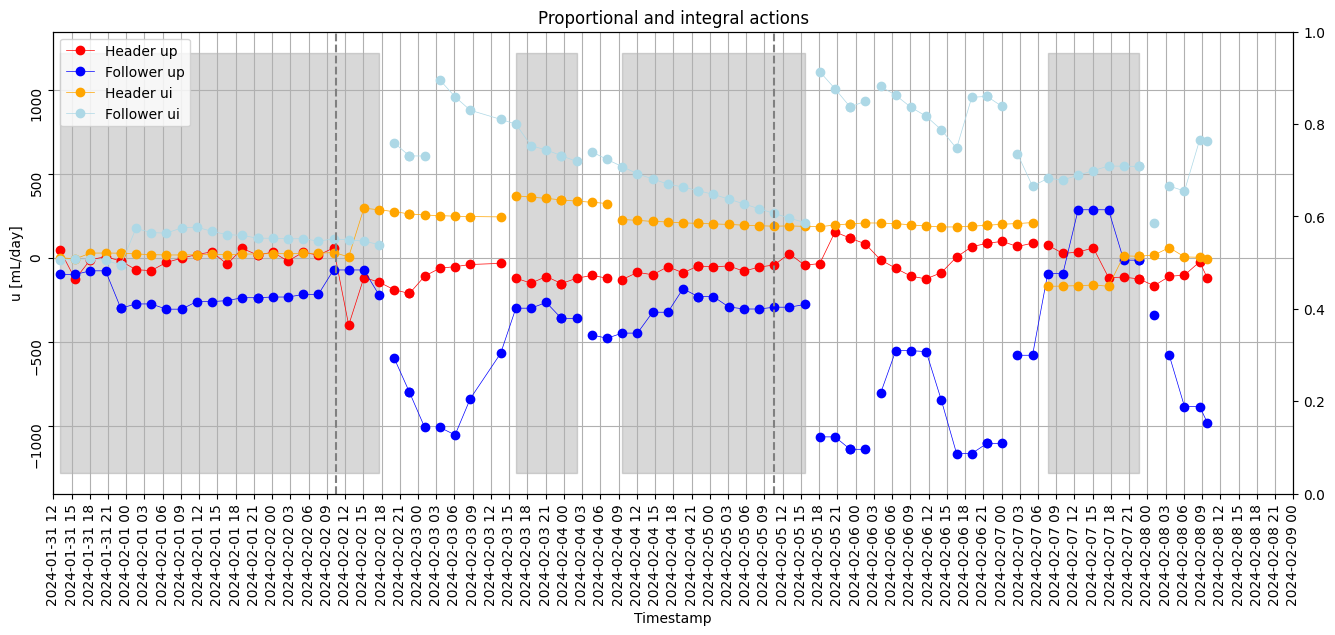

In [10]:
# PLOT of boundary conditions + outputs
df1 = result['Header']
df2 = result['Follower']
df1['timestamp'] = pd.to_datetime(df1['timestamp'])
df2['timestamp'] = pd.to_datetime(df2['timestamp'])
# Plot the overall time series
fig, ax1 = plt.subplots(figsize=(16, 6))
ax1.plot(df1['timestamp'], df1['u_p']*1e6, color='r', label='Header up',linewidth=0.5,marker='o')
ax1.plot(df2['timestamp'], df2['u_p']*1e6, color='b', label='Follower up',linewidth=0.5,marker='o')
ax1.plot(df1['timestamp'], df1['u_i']*1e6, color='orange', label='Header ui',linewidth=0.5,marker='o')
ax1.plot(df2['timestamp'], df2['u_i']*1e6, color='lightblue', label='Follower ui',linewidth=0.5,marker='o')
ax1.set_xlabel('Timestamp')
ax1.set_ylabel('u [mL/day]')
ax1.legend(loc='upper left')
#ax = plt.gca()
#-----------------------------------------------------------------------------------------------------
# Create a second y-axis sharing the same x-axis
ax2 = ax1.twinx()
#ax2.plot(df2['Timestamp_control'], df2['final_control_signal']*1e6, color='g', label='final_control_signal',linewidth=0.5,marker='o')
#ax2.set_ylabel('u')
#ax2.legend(loc='upper right')
#-----------------------------------------------------------------------------------------------------
# Add vertical dotted lines at specific time instants
specific_time_instants = ['2024-1-31 10:30','2024-2-2 10:30',
                          '2024-2-5 10:30'
                         ]
for time_instant in specific_time_instants:
    ax1.axvline(pd.to_datetime(time_instant), color='grey', linestyle='dashed')#, label=f'{time_instant}')
#----------------------------------------------------------------------------------------------------
# Set x-axis formatting to display dates as 'YYYY-MM-DD'
date_format = mdates.DateFormatter('%Y-%m-%d')
ax2.xaxis.set_major_formatter(date_format)

# Set the locator for the x-axis to show every day
ax2.xaxis.set_major_locator(mdates.DayLocator(interval=1))

# Set x-axis limits with timestamps (from 10:30 AM to 12:30 PM)
start_time = '2024-01-31 12:00:00'
end_time = '2024-02-09 00:00:00'
ax2.set_xlim(mdates.date2num(np.datetime64(start_time)), mdates.date2num(np.datetime64(end_time)))
#ax = plt.gca()

#ax.set_ylim([42, 42.4])
#ax.set_xlim([15000,15015])

# Set x-axis formatting to display dates as 'YYYY-MM-DD'
date_format = mdates.DateFormatter('%Y-%m-%d %H') #('%Y-%m-%d %H:%m')
ax2.xaxis.set_major_formatter(date_format)

# Set the locator for the x-axis to show every day
ax2.xaxis.set_major_locator(mdates.HourLocator(interval=3))

# Fill the area where the specified column contains the specified value with grey color
#mask = df1['selection'] == 'True'
#ax2.fill_between(df1['timestamp'], ax2.get_ylim()[0], ax2.get_ylim()[1], where=mask, color='grey', alpha=0.3)
mask = result['Output_selector']['active'] == 'Header'
ax1.fill_between(result['Output_selector']['Timestamp_control'], ax1.get_ylim()[0], ax1.get_ylim()[1], where=mask, color='grey', alpha=0.3)

plt.title('Proportional and integral actions')
ax1.tick_params(rotation=90)
#ax1.tight_layout()
ax1.grid()
plt.show()